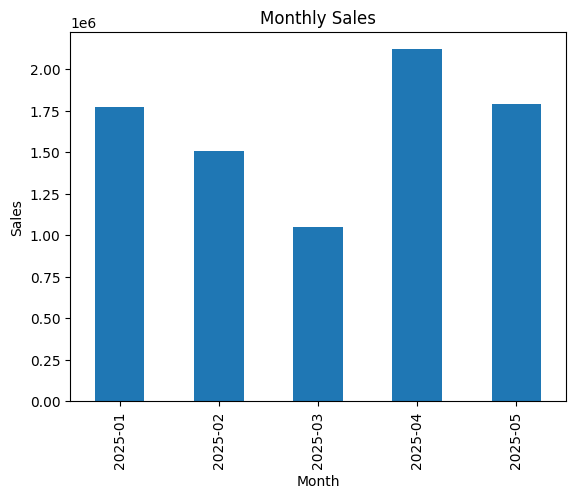

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/sales_data.csv")

df["total_price"] = df["price"] * df["quantity"]
df["order_date"] = pd.to_datetime(df["order_date"])
df["month"] = df["order_date"].dt.to_period("M")

monthly_sales = df.groupby("month")["total_price"].sum()

monthly_sales.plot(kind="bar")

plt.title("Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [8]:
product_quantity = df.groupby("product_name")["quantity"].sum().sort_values(ascending=False)

product_quantity

product_name
Pen         45
Notebook    23
Mouse       12
Chair        5
Keyboard     5
Desk         4
Laptop       4
Monitor      3
Name: quantity, dtype: int64

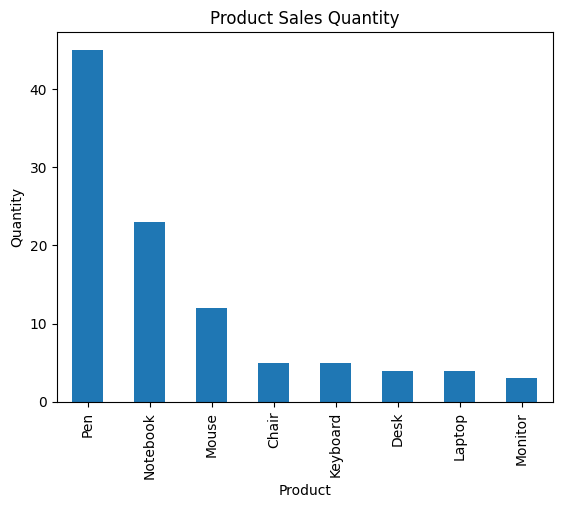

In [9]:
product_quantity.plot(kind="bar")

plt.title("Product Sales Quantity")
plt.xlabel("Product")
plt.ylabel("Quantity")
plt.show()

In [10]:
product_sales = df.groupby("product_name")["total_price"].sum().sort_values(ascending=False)
product_sales

product_name
Laptop      4800000
Desk        1000000
Monitor      900000
Chair        750000
Keyboard     350000
Mouse        300000
Notebook      69000
Pen           67500
Name: total_price, dtype: int64

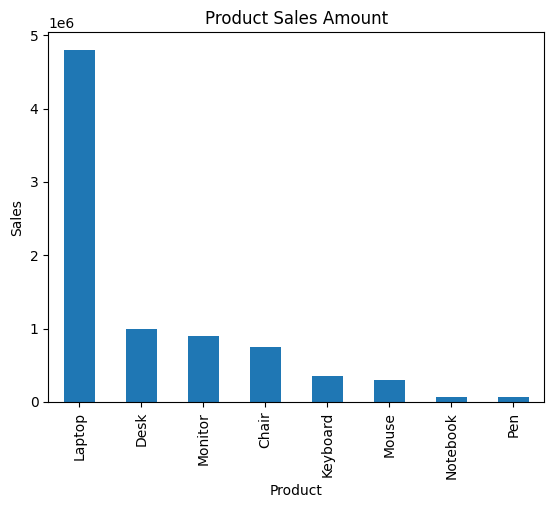

In [11]:
product_sales.plot(kind="bar")

plt.title("Product Sales Amount")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

In [12]:
category_sales = df.groupby("category")["total_price"].sum().sort_values(ascending=False)
category_sales

category
Electronics    6350000
Furniture      1750000
Stationery      136500
Name: total_price, dtype: int64

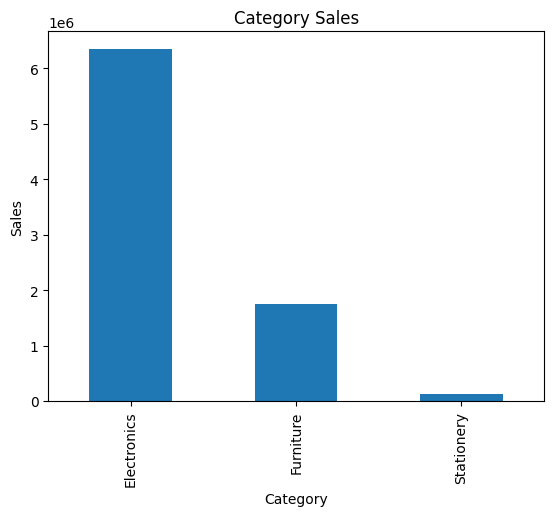

In [13]:
category_sales.plot(kind="bar")

plt.title("Category Sales")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

In [14]:
category_quantity = df.groupby("category")["quantity"].sum().sort_values(ascending=False)
category_quantity

category
Stationery     68
Electronics    24
Furniture       9
Name: quantity, dtype: int64

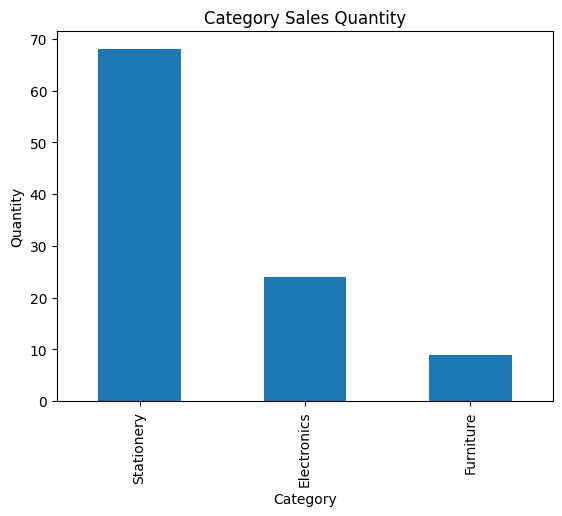

In [15]:
category_quantity.plot(kind="bar")

plt.title("Category Sales Quantity")
plt.xlabel("Category")
plt.ylabel("Quantity")
plt.show()

In [16]:
df.head()

,order_id,customer_id,product_name,category,price,quantity,order_date,total_price,month
0,1,C001,Laptop,Electronics,1200000,1,2025-01-05,1200000,2025-01
1,2,C002,Mouse,Electronics,25000,2,2025-01-07,50000,2025-01
2,3,C003,Keyboard,Electronics,70000,1,2025-01-10,70000,2025-01
3,4,C001,Monitor,Electronics,300000,1,2025-01-15,300000,2025-01
4,5,C004,Chair,Furniture,150000,1,2025-01-20,150000,2025-01


In [17]:
customer_sales = df.groupby("customer_id")["total_price"].sum().sort_values(ascending=False)

customer_sales

customer_id
C001    2775000
C003    1420000
C006    1215000
C005     500000
C004     400000
C009     390000
C007     385000
C008     350000
C010     330000
C012     280000
C002     145000
C011      46500
Name: total_price, dtype: int64

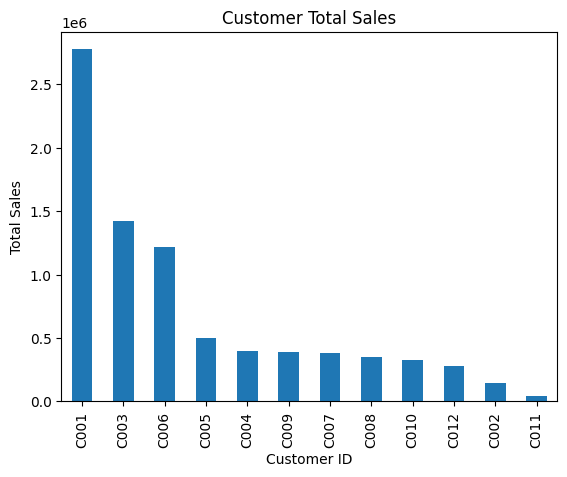

In [18]:
customer_sales.plot(kind="bar")

plt.title("Customer Total Sales")
plt.xlabel("Customer ID")
plt.ylabel("Total Sales")
plt.show()

In [19]:
customer_order_count = df.groupby("customer_id")["order_id"].count().sort_values(ascending=False)

customer_order_count

customer_id
C001    4
C002    3
C003    3
C005    3
C007    3
C004    2
C006    2
C008    2
C009    2
C010    2
C011    2
C012    2
Name: order_id, dtype: int64

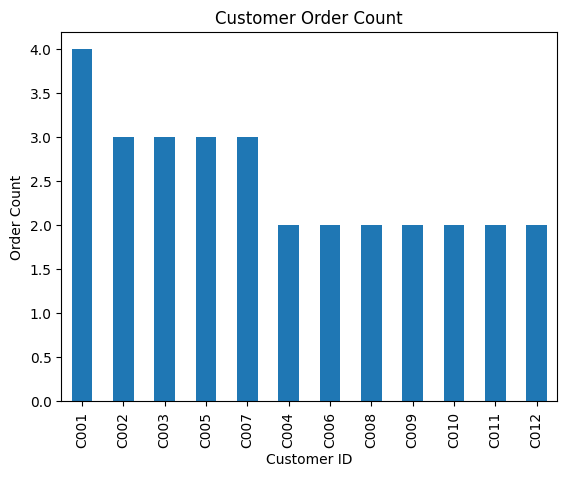

In [20]:
customer_order_count.plot(kind="bar")

plt.title("Customer Order Count")
plt.xlabel("Customer ID")
plt.ylabel("Order Count")
plt.show()

In [21]:
customer_avg_sales = df.groupby("customer_id")["total_price"].mean().sort_values(ascending=False)

customer_avg_sales

customer_id
C001    693750.000000
C006    607500.000000
C003    473333.333333
C004    200000.000000
C009    195000.000000
C008    175000.000000
C005    166666.666667
C010    165000.000000
C012    140000.000000
C007    128333.333333
C002     48333.333333
C011     23250.000000
Name: total_price, dtype: float64

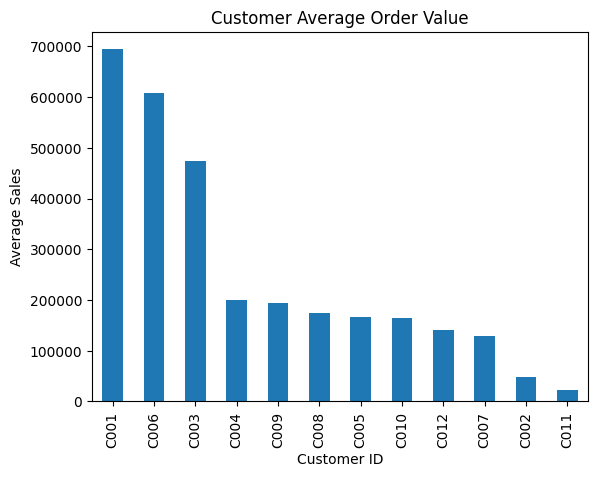

In [22]:
customer_avg_sales.plot(kind="bar")

plt.title("Customer Average Order Value")
plt.xlabel("Customer ID")
plt.ylabel("Average Sales")
plt.show()

In [23]:
customer_summary = df.groupby("customer_id").agg(
    order_count=("order_id", "count"),
    total_spent=("total_price", "sum"),
    avg_order_value=("total_price", "mean"),
    first_order_date=("order_date", "min"),
    last_order_date=("order_date", "max")
)

customer_summary

,order_count,total_spent,avg_order_value,first_order_date,last_order_date
customer_id,,,,,
C001,4,2775000,693750.000000,2025-01-05,2025-05-05
C002,3,145000,48333.333333,2025-01-07,2025-03-12
C003,3,1420000,473333.333333,2025-01-10,2025-05-08
C004,2,400000,200000.000000,2025-01-20,2025-04-01
C005,3,500000,166666.666667,2025-02-03,2025-05-10
C006,2,1215000,607500.000000,2025-02-08,2025-04-05
C007,3,385000,128333.333333,2025-02-12,2025-05-15
C008,2,350000,175000.000000,2025-03-01,2025-04-12
C009,2,390000,195000.000000,2025-03-03,2025-04-15


In [24]:
customer_summary.sort_values("last_order_date", ascending=False)

,order_count,total_spent,avg_order_value,first_order_date,last_order_date
customer_id,,,,,
C007,3,385000,128333.333333,2025-02-12,2025-05-15
C005,3,500000,166666.666667,2025-02-03,2025-05-10
C003,3,1420000,473333.333333,2025-01-10,2025-05-08
C001,4,2775000,693750.000000,2025-01-05,2025-05-05
C012,2,280000,140000.000000,2025-03-18,2025-05-03
C011,2,46500,23250.000000,2025-03-15,2025-05-01
C010,2,330000,165000.000000,2025-03-05,2025-04-20
C009,2,390000,195000.000000,2025-03-03,2025-04-15
C008,2,350000,175000.000000,2025-03-01,2025-04-12


In [25]:
customer_summary["is_repurchase_customer"] = customer_summary["order_count"] >= 2

customer_summary

,order_count,total_spent,avg_order_value,first_order_date,last_order_date,is_repurchase_customer
customer_id,,,,,,
C001,4,2775000,693750.000000,2025-01-05,2025-05-05,True
C002,3,145000,48333.333333,2025-01-07,2025-03-12,True
C003,3,1420000,473333.333333,2025-01-10,2025-05-08,True
C004,2,400000,200000.000000,2025-01-20,2025-04-01,True
C005,3,500000,166666.666667,2025-02-03,2025-05-10,True
C006,2,1215000,607500.000000,2025-02-08,2025-04-05,True
C007,3,385000,128333.333333,2025-02-12,2025-05-15,True
C008,2,350000,175000.000000,2025-03-01,2025-04-12,True
C009,2,390000,195000.000000,2025-03-03,2025-04-15,True


In [26]:
customer_summary["is_repurchase_customer"].value_counts()

is_repurchase_customer
True    12
Name: count, dtype: int64

In [27]:
customer_summary["is_repurchase_customer"].value_counts(normalize=True)

is_repurchase_customer
True    1.0
Name: proportion, dtype: float64

In [28]:
repurchase_rate = customer_summary["is_repurchase_customer"].mean() * 100

print(f"Repurchase Rate: {repurchase_rate:.2f}%")

Repurchase Rate: 100.00%


In [29]:
customer_summary.groupby("is_repurchase_customer")["total_spent"].mean()

is_repurchase_customer
True    686375.0
Name: total_spent, dtype: float64

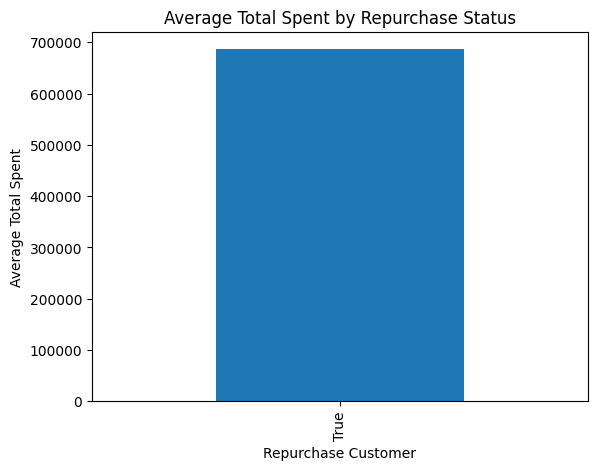

In [30]:
customer_summary.groupby("is_repurchase_customer")["total_spent"].mean().plot(kind="bar")

plt.title("Average Total Spent by Repurchase Status")
plt.xlabel("Repurchase Customer")
plt.ylabel("Average Total Spent")
plt.show()

In [31]:
top_customer = customer_summary["total_spent"].idxmax()
top_customer_amount = customer_summary["total_spent"].max()

most_frequent_customer = customer_summary["order_count"].idxmax()
most_frequent_count = customer_summary["order_count"].max()

repurchase_rate = customer_summary["is_repurchase_customer"].mean() * 100

print(f"가장 구매금액이 높은 고객: {top_customer}, 총 구매금액: {top_customer_amount:,.0f}원")
print(f"가장 구매 횟수가 많은 고객: {most_frequent_customer}, 구매 횟수: {most_frequent_count}회")
print(f"재구매 고객 비율: {repurchase_rate:.2f}%")

가장 구매금액이 높은 고객: C001, 총 구매금액: 2,775,000원
가장 구매 횟수가 많은 고객: C001, 구매 횟수: 4회
재구매 고객 비율: 100.00%


In [32]:
customer_summary.head()

,order_count,total_spent,avg_order_value,first_order_date,last_order_date,is_repurchase_customer
customer_id,,,,,,
C001,4,2775000,693750.000000,2025-01-05,2025-05-05,True
C002,3,145000,48333.333333,2025-01-07,2025-03-12,True
C003,3,1420000,473333.333333,2025-01-10,2025-05-08,True
C004,2,400000,200000.000000,2025-01-20,2025-04-01,True
C005,3,500000,166666.666667,2025-02-03,2025-05-10,True


In [33]:
X = customer_summary[["total_spent", "avg_order_value"]]
y = customer_summary["is_repurchase_customer"]

X.head()

,total_spent,avg_order_value
customer_id,,
C001,2775000,693750.000000
C002,145000,48333.333333
C003,1420000,473333.333333
C004,400000,200000.000000
C005,500000,166666.666667


In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8, 2)
X_test: (4, 2)
y_train: (8,)
y_test: (4,)


In [53]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [56]:
y_pred = model.predict(X_test)

In [55]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

Accuracy: 1.00


In [57]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred, labels=[False, True]))

print("Classification Report:")
print(classification_report(y_test, y_pred, labels=[False, True]))

Accuracy: 1.00
Confusion Matrix:
[[0 0]
 [0 4]]
Classification Report:
              precision    recall  f1-score   support

       False       0.00      0.00      0.00         0
        True       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       0.50      0.50      0.50         4
weighted avg       1.00      1.00      1.00         4



/Users/honggyupark/sales-analysis-project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/honggyupark/sales-analysis-project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/honggyupark/sales-analysis-project/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn

In [48]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        True       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4



In [58]:
result = X_test.copy()
result["actual"] = y_test
result["predicted"] = y_pred

result

,total_spent,avg_order_value,actual,predicted
customer_id,,,,
C007,385000,128333.333333,True,True
C004,400000,200000.000000,True,True
C005,500000,166666.666667,True,True
C008,350000,175000.000000,True,True


In [59]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

total_spent        0.0
avg_order_value    0.0
dtype: float64

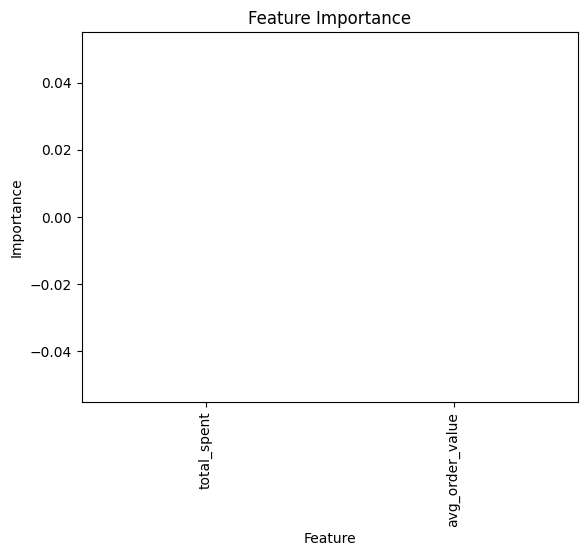

In [60]:
feature_importance.plot(kind="bar")

plt.title("Feature Importance")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()

In [ ]:
#分類モデルの評価時には、目的変数のクラス比率を考慮するため、train_test_splitでstratifyを指定しました。